# Non-cheatable ICL: multiple tasks

Generalizes the analysis from the repetition task to other 'real ICL' tasks. Tests whether patterns observed for repetition (output→input head ablation crashing accuracy, manipulation sweep profiles) generalize across tasks with no output-vocabulary shortcut.

**Tasks tested:**
- `repetition`: input → input+input (`blorm → blormblorm`). Variable input length 4-7.
- `prepend_first`: input → first_char + input (`blorm → bblorm`). Variable input length 4-7.
- `first_char`: input → first char (`blorm → b`). Variable input length 4-8.

All tasks use nonsense words. 50 prompts of 10 demos each per task.

**Confound notes.** Each task has a structural regularity in outputs (all doubled, all start with doubled char, all single char). The manipulation sweep tests whether these confounds drive the behavior: if star_inputs (output structure preserved, input content destroyed) crashes to 0%, the model needs actual pairings, not output structure alone.

In [1]:
import sys; sys.path.insert(0, '../..')
import torch, numpy as np, matplotlib.pyplot as plt, random, seaborn as sns
import pandas as pd, pickle
from collections import defaultdict
from tqdm import tqdm
from math import sqrt
from transformer_lens import HookedTransformer
from configs import *
from utils import *
%matplotlib inline

sns.set_context('notebook')

model = HookedTransformer.from_pretrained(MODEL_NAME, device='cuda', dtype=torch.float16)
model.eval()
n_layers = model.cfg.n_layers
n_heads  = model.cfg.n_heads
PATTERN_FILTER = lambda name: 'attn.hook_pattern' in name

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-28 09:34:48.183967: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.22it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer


## Multi-token correctness check (whitespace-normalized)

In [2]:
@torch.no_grad()
def check_correct_multitoken(model, tokens, expected, max_new_tokens=16, hooks=None):
    def _normalize(s): return ''.join(s.split()).lower()
    target = _normalize(expected)
    generated = []
    cur = tokens.clone()
    for _ in range(max_new_tokens):
        if hooks:
            logits = model.run_with_hooks(cur, fwd_hooks=hooks)[0, -1]
        else:
            logits = model(cur)[0, -1]
        nt = logits.argmax().item()
        generated.append(nt)
        cur = torch.cat([cur, torch.tensor([[nt]], device=cur.device)], dim=1)
        decoded = _normalize(model.tokenizer.decode(generated))
        if decoded and not target.startswith(decoded): return 0
        if decoded.startswith(target): return 1
    return int(_normalize(model.tokenizer.decode(generated)).startswith(target))

@torch.no_grad()
def target_logprob_with_hooks(model, tokens, expected, hooks=None):
    target_ids = model.to_tokens(' ' + expected.strip(), prepend_bos=False)[0].tolist()
    total = 0.0
    cur = tokens.clone()
    for tok in target_ids:
        if hooks:
            logits = model.run_with_hooks(cur, fwd_hooks=hooks)[0, -1]
        else:
            logits = model(cur)[0, -1]
        log_probs = torch.log_softmax(logits.float(), dim=-1)
        total += log_probs[tok].item()
        cur = torch.cat([cur, torch.tensor([[tok]], device=cur.device)], dim=1)
    return total

def answer_rank(model, logits, answer):
    ans_tok = model.to_tokens(' ' + answer, prepend_bos=False)[0, 0].item()
    return int((logits > logits[ans_tok]).sum().item())

## Task generators

In [3]:
CONSONANTS = 'bdfghjklmnprstvwz'
VOWELS = 'aeiou'

def make_nonsense(length, _rng):
    pattern = [CONSONANTS, VOWELS] * (length // 2 + 1)
    return ''.join(_rng.choice(p) for p in pattern[:length])

def gen_repetition(rng):
    """input → input+input. Variable input length 4-7."""
    inputs = []
    while len(set(inputs)) < 11:
        inputs = [make_nonsense(rng.choice([4, 5, 6, 7]), rng) for _ in range(11)]
    demo_pairs = [(i, i + i) for i in inputs[:10]]
    qi = inputs[10]; qo = qi + qi
    return demo_pairs, qi, qo

def gen_prepend_first(rng):
    """input → first_char + input. Variable input length 4-7."""
    inputs = []
    while len(set(inputs)) < 11:
        inputs = [make_nonsense(rng.choice([4, 5, 6, 7]), rng) for _ in range(11)]
    demo_pairs = [(i, i[0] + i) for i in inputs[:10]]
    qi = inputs[10]; qo = qi[0] + qi
    return demo_pairs, qi, qo

def gen_first_char(rng):
    """input → first char. Variable input length 4-8."""
    inputs = []
    while len(set(inputs)) < 11:
        inputs = [make_nonsense(rng.choice([4, 5, 6, 7, 8]), rng) for _ in range(11)]
    demo_pairs = [(i, i[0]) for i in inputs[:10]]
    qi = inputs[10]; qo = qi[0]
    return demo_pairs, qi, qo

TASK_GENERATORS = {
    'repetition':   gen_repetition,
    'prepend_first': gen_prepend_first,
    'first_char':   gen_first_char,
}

N_PROMPTS_PER_TASK = 50

def build_prompts_data(task_name, n_prompts, seed):
    rng = random.Random(seed)
    gen = TASK_GENERATORS[task_name]
    out = []
    for _ in range(n_prompts):
        demo_pairs, qi, qo = gen(rng)
        prompt = build_icl_prompt(demo_pairs, qi)
        out.append({
            'demo_pairs': demo_pairs, 'query_input': qi,
            'query_output': qo, 'prompt': prompt,
        })
    return out

TASKS = {name: build_prompts_data(name, N_PROMPTS_PER_TASK, seed=hash(name) % 10**6)
         for name in TASK_GENERATORS}
TASK_NAMES = list(TASKS.keys())

for name in TASK_NAMES:
    p0 = TASKS[name][0]
    in_lens  = sorted(set(len(i) for i, _ in p0['demo_pairs']))
    out_lens = sorted(set(len(o) for _, o in p0['demo_pairs']))
    print(f'{name}:')
    print(f'  example: {p0["demo_pairs"][0][0]} → {p0["demo_pairs"][0][1]}')
    print(f'  query: {p0["query_input"]} → {p0["query_output"]}')
    print(f'  input lengths: {in_lens}, output lengths: {out_lens}')

repetition:
  example: dotevuk → dotevukdotevuk
  query: zere → zerezere
  input lengths: [4, 5, 6, 7], output lengths: [8, 10, 12, 14]
prepend_first:
  example: disid → ddisid
  query: zugewo → zzugewo
  input lengths: [4, 5, 6, 7], output lengths: [5, 6, 7, 8]
first_char:
  example: bubebati → b
  query: topime → t
  input lengths: [4, 6, 7, 8], output lengths: [1]


## Sanity checks: orig and query-only per task

In [5]:
# === Focused star_inputs check on remaining candidates ===
@torch.no_grad()
def _show_gen(model, tokens, max_new_tokens=12):
    cur = tokens.clone()
    generated = []
    for _ in range(max_new_tokens):
        logits = model(cur)[0, -1]
        nt = logits.argmax().item()
        generated.append(nt)
        cur = torch.cat([cur, torch.tensor([[nt]], device=cur.device)], dim=1)
    return model.tokenizer.decode(generated)

CANDIDATES = [
    ('first_2_L5',     5, lambda s: s[:2]),
    ('first_2_L7',     7, lambda s: s[:2]),
    ('first_char_L5',  5, lambda s: s[0]),     # retest with fixed length for comparison
    ('prepend_first_L5', 5, lambda s: s[0] + s),  # fixed length version
]

N_TEST = 50
for cname, length, rule in CANDIDATES:
    _rng = random.Random(0)
    test_prompts = []
    for _ in range(N_TEST):
        inputs = []
        while len(set(inputs)) < 11:
            inputs = [make_nonsense(length, _rng) for _ in range(11)]
        demo_pairs = [(i, rule(i)) for i in inputs[:10]]
        qi = inputs[10]; qo = rule(qi)
        prompt = build_icl_prompt(demo_pairs, qi)
        test_prompts.append({'demo_pairs': demo_pairs, 'query_input': qi,
                             'query_output': qo, 'prompt': prompt})
    
    orig_correct = []; star_correct = []; mean_correct = []; random_correct = []; qo_correct = []
    
    all_inputs = [inp for p in test_prompts for inp, _ in p['demo_pairs']]
    
    for pdata in tqdm(test_prompts, desc=cname):
        qi = pdata['query_input']; ans = pdata['query_output']
        outputs = [o for _, o in pdata['demo_pairs']]
        inputs  = [i for i, _ in pdata['demo_pairs']]
        
        # Orig
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        orig_correct.append(check_correct_multitoken(model, tokens, ans))
        
        # Star inputs
        star_prompt = build_icl_prompt([('*', o) for o in outputs], qi)
        star_tokens = model.to_tokens(star_prompt, prepend_bos=True)
        star_correct.append(check_correct_multitoken(model, star_tokens, ans))
        
        # Random inputs
        random_inputs = [_rng.choice(all_inputs) for _ in inputs]
        rand_prompt = build_icl_prompt(list(zip(random_inputs, outputs)), qi)
        rand_tokens = model.to_tokens(rand_prompt, prepend_bos=True)
        random_correct.append(check_correct_multitoken(model, rand_tokens, ans))
        
        # Query only
        zs_tokens = model.to_tokens(f'{qi} \u2192', prepend_bos=True)
        qo_correct.append(check_correct_multitoken(model, zs_tokens, ans))
        
        torch.cuda.empty_cache()
    
    print(f'\n=== {cname} ===')
    print(f'  Orig:   {np.mean(orig_correct):.3f}')
    print(f'  Star:   {np.mean(star_correct):.3f}')
    print(f'  Random: {np.mean(random_correct):.3f}')
    print(f'  QO:     {np.mean(qo_correct):.3f}')
    print(f'  Example: {test_prompts[0]["demo_pairs"][0][0]} \u2192 {test_prompts[0]["demo_pairs"][0][1]}')

first_2_L5: 100%|██████████| 50/50 [00:10<00:00,  4.73it/s]



=== first_2_L5 ===
  Orig:   1.000
  Star:   0.140
  Random: 0.180
  QO:     0.000
  Example: sodiz → so


first_2_L7: 100%|██████████| 50/50 [00:10<00:00,  4.59it/s]



=== first_2_L7 ===
  Orig:   0.960
  Star:   0.120
  Random: 0.020
  QO:     0.000
  Example: sodizos → so


first_char_L5: 100%|██████████| 50/50 [00:10<00:00,  5.00it/s]



=== first_char_L5 ===
  Orig:   0.980
  Star:   0.300
  Random: 0.120
  QO:     0.060
  Example: sodiz → s


prepend_first_L5: 100%|██████████| 50/50 [00:14<00:00,  3.37it/s]


=== prepend_first_L5 ===
  Orig:   0.960
  Star:   0.000
  Random: 0.040
  QO:     0.000
  Example: sodiz → ssodiz


: 

In [20]:
sanity = {name: {'orig': [], 'query_only': []} for name in TASK_NAMES}

for name in TASK_NAMES:
    for pdata in tqdm(TASKS[name], desc=f'{name}'):
        # orig
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        sanity[name]['orig'].append(check_correct_multitoken(model, tokens, pdata['query_output']))
        # query-only
        zs = f'{pdata["query_input"]} \u2192'
        zs_tokens = model.to_tokens(zs, prepend_bos=True)
        sanity[name]['query_only'].append(check_correct_multitoken(model, zs_tokens, pdata['query_output']))
        torch.cuda.empty_cache()

print(f'\n{"Task":<20} {"Orig":>8}  {"Query-only":>12}')
print('-' * 44)
for name in TASK_NAMES:
    o = np.mean(sanity[name]['orig'])
    q = np.mean(sanity[name]['query_only'])
    print(f'{name:<20} {o:>8.3f}  {q:>12.3f}')

first_char: 100%|██████████| 50/50 [00:05<00:00,  8.57it/s]


Task                     Orig    Query-only
--------------------------------------------
repetition              0.900         0.000
prepend_first           0.840         0.000
first_char              0.980         0.040


## Build per-task input and output pools (used for random-from-pool conditions and mean embeddings)

In [21]:
W_E = model.W_E.detach()
task_pools = {}
for name, prompts_data in TASKS.items():
    in_pool = []; in_tokids = []
    out_pool = []; out_tokids = []
    for pdata in prompts_data:
        for inp, out in pdata['demo_pairs']:
            in_pool.append(inp)
            in_tokids.append(model.to_tokens(' ' + inp, prepend_bos=False)[0, 0].item())
            out_pool.append(out)
            out_tokids.append(model.to_tokens(' ' + out, prepend_bos=False)[0, 0].item())
    task_pools[name] = {
        'in_pool': in_pool, 'out_pool': out_pool,
        'mean_in_embed':  W_E[in_tokids].mean(dim=0),
        'mean_out_embed': W_E[out_tokids].mean(dim=0),
    }
    print(f'{name}: |in_pool|={len(in_pool)}, |out_pool|={len(out_pool)}')

repetition: |in_pool|=500, |out_pool|=500
prepend_first: |in_pool|=500, |out_pool|=500
first_char: |in_pool|=500, |out_pool|=500


## Manipulation sweep: accuracy and log-prob across all conditions, per task

Conditions: orig, shuffled_inputs, random_inputs, mean_embed_inputs, star_inputs, shuffled_outputs, random_outputs, mean_embed_outputs, star_outputs, query_only.

In [22]:
def make_embed_hook(positions, replacement_vec):
    def hook_fn(emb, hook):
        for p in positions: emb[:, p, :] = replacement_vec.to(emb.dtype)
        return emb
    return hook_fn

CONDS = ['orig', 'shuffled_inputs', 'random_inputs', 'mean_embed_inputs', 'star_inputs',
         'shuffled_outputs', 'random_outputs', 'mean_embed_outputs', 'star_outputs',
         'query_only']

task_correct = {name: {c: [] for c in CONDS} for name in TASK_NAMES}
task_logp    = {name: {c: [] for c in CONDS} for name in TASK_NAMES}

for name in TASK_NAMES:
    rng = random.Random(7)
    pools = task_pools[name]
    for pdata in tqdm(TASKS[name], desc=f'{name} sweep'):
        demos = pdata['demo_pairs']
        qi = pdata['query_input']; ans = pdata['query_output']
        inputs  = [i for i, _ in demos]
        outputs = [o for _, o in demos]
        inputs_shuffled  = inputs.copy();  rng.shuffle(inputs_shuffled)
        outputs_shuffled = outputs.copy(); rng.shuffle(outputs_shuffled)
        inputs_random    = [rng.choice(pools['in_pool'])  for _ in inputs]
        outputs_random   = [rng.choice(pools['out_pool']) for _ in outputs]
        prompts = {
            'orig':              pdata['prompt'],
            'shuffled_inputs':   build_icl_prompt(list(zip(inputs_shuffled, outputs)), qi),
            'random_inputs':     build_icl_prompt(list(zip(inputs_random, outputs)), qi),
            'star_inputs':       build_icl_prompt([('*', o) for o in outputs], qi),
            'shuffled_outputs':  build_icl_prompt(list(zip(inputs, outputs_shuffled)), qi),
            'random_outputs':    build_icl_prompt(list(zip(inputs, outputs_random)), qi),
            'star_outputs':      build_icl_prompt([(i, '*') for i in inputs], qi),
            'query_only':        f'{qi} \u2192',
        }
        tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}
        
        for k in prompts:
            task_correct[name][k].append(check_correct_multitoken(model, tokens[k], ans))
            task_logp[name][k].append(target_logprob_with_hooks(model, tokens[k], ans))
        
        per_demo = find_per_demo_positions(model, prompts['orig'], demos)
        in_pos  = [p for d in per_demo for p in d.get('input_positions', [])]
        out_pos = [p for d in per_demo for p in d.get('output_positions', [])]
        
        h_in  = [('hook_embed', make_embed_hook(in_pos,  pools['mean_in_embed']))]
        task_correct[name]['mean_embed_inputs'].append(
            check_correct_multitoken(model, tokens['orig'], ans, hooks=h_in))
        task_logp[name]['mean_embed_inputs'].append(
            target_logprob_with_hooks(model, tokens['orig'], ans, hooks=h_in))
        
        h_out = [('hook_embed', make_embed_hook(out_pos, pools['mean_out_embed']))]
        task_correct[name]['mean_embed_outputs'].append(
            check_correct_multitoken(model, tokens['orig'], ans, hooks=h_out))
        task_logp[name]['mean_embed_outputs'].append(
            target_logprob_with_hooks(model, tokens['orig'], ans, hooks=h_out))
        
        torch.cuda.empty_cache()
    
    for c in CONDS:
        task_correct[name][c] = np.array(task_correct[name][c])
        task_logp[name][c]    = np.array(task_logp[name][c])

print('\nSweep complete')

first_char sweep: 100%|██████████| 50/50 [00:41<00:00,  1.20it/s]


Sweep complete


/tmp/ipykernel_3502812/953624095.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='Correct', order=order_labels,
/tmp/ipykernel_3502812/953624095.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='Correct', order=order_labels,
/tmp/ipykernel_3502812/953624095.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='Correct', order=order_labels,


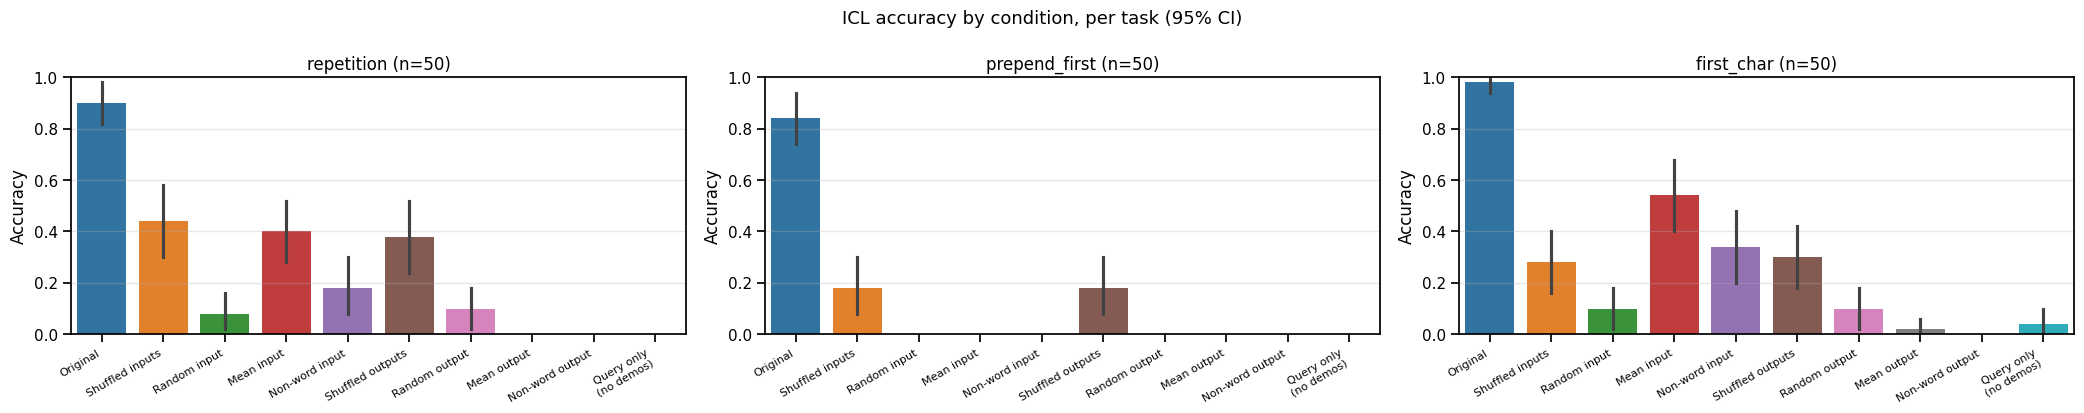

In [23]:
tick_map = {
    'orig':                'Original',
    'shuffled_inputs':     'Shuffled inputs',
    'random_inputs':       'Random input',
    'mean_embed_inputs':   'Mean input',
    'star_inputs':         'Non-word input',
    'shuffled_outputs':    'Shuffled outputs',
    'random_outputs':      'Random output',
    'mean_embed_outputs':  'Mean output',
    'star_outputs':        'Non-word output',
    'query_only':          'Query only\n(no demos)',
}
order_keys = CONDS
order_labels = [tick_map[c] for c in order_keys]

n_t = len(TASK_NAMES)
n_cols = min(n_t, 3)
n_rows = int(np.ceil(n_t / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 4.2*n_rows))
if hasattr(axes, "flatten"): axes = axes.flatten()
else: axes = [axes]
for ax, name in zip(axes, TASK_NAMES):
    correct = task_correct[name]
    df = pd.DataFrame({
        'Condition': np.concatenate([[tick_map[c]] * len(correct[c]) for c in order_keys]),
        'Correct':   np.concatenate([correct[c] for c in order_keys]),
    })
    sns.barplot(data=df, x='Condition', y='Correct', order=order_labels,
                palette='tab10', errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylabel('Accuracy'); ax.set_xlabel('')
    ax.set_ylim(0, 1.0)
    ax.set_title(f'{name} (n={len(correct["orig"])})')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
for ax in axes[len(TASK_NAMES):]: ax.set_visible(False)
fig.suptitle('ICL accuracy by condition, per task (95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

/tmp/ipykernel_3502812/480585851.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='LogProb', order=order_labels,
/tmp/ipykernel_3502812/480585851.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='LogProb', order=order_labels,
/tmp/ipykernel_3502812/480585851.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='LogProb', order=order_labels,


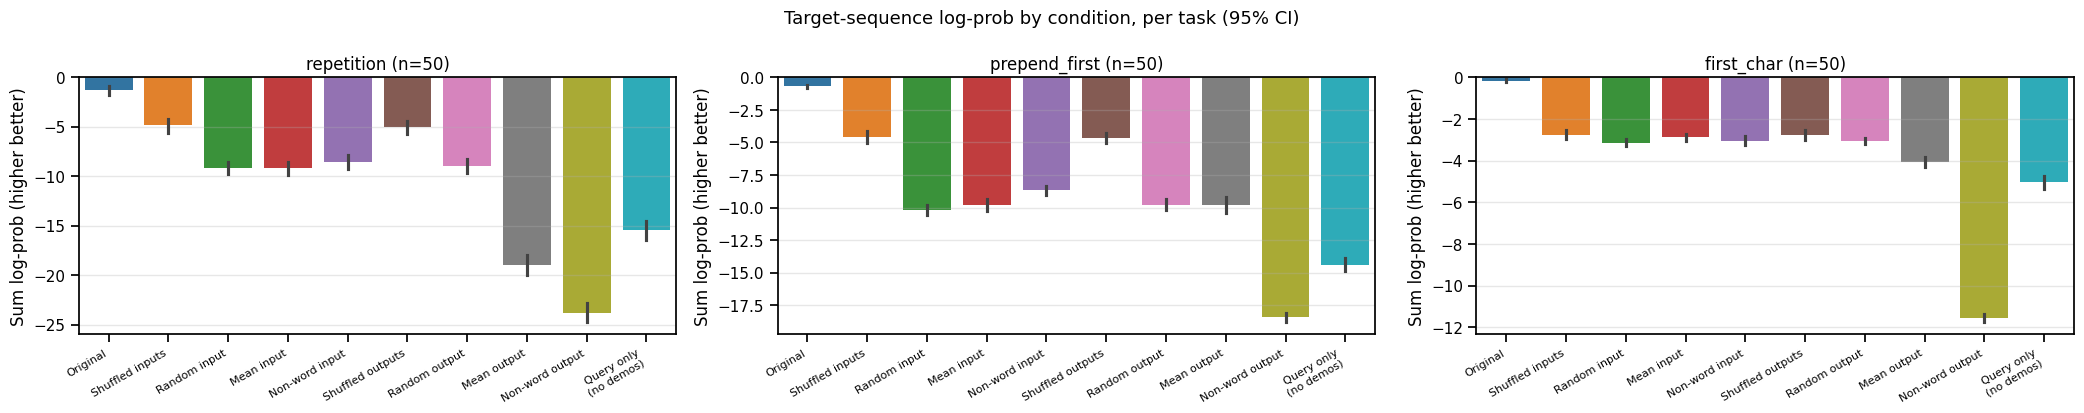

In [24]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 4.2*n_rows))
if hasattr(axes, "flatten"): axes = axes.flatten()
else: axes = [axes]
for ax, name in zip(axes, TASK_NAMES):
    logp = task_logp[name]
    df = pd.DataFrame({
        'Condition': np.concatenate([[tick_map[c]] * len(logp[c]) for c in order_keys]),
        'LogProb':   np.concatenate([logp[c] for c in order_keys]),
    })
    sns.barplot(data=df, x='Condition', y='LogProb', order=order_labels,
                palette='tab10', errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylabel('Sum log-prob (higher better)'); ax.set_xlabel('')
    ax.set_title(f'{name} (n={len(logp["orig"])})')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
for ax in axes[len(TASK_NAMES):]: ax.set_visible(False)
fig.suptitle('Target-sequence log-prob by condition, per task (95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

# Output→input head ablation

Score heads with the baseline-subtracted output→input score on each task, then ablate top 10% and a size-matched random control. Compare ICL accuracy under each ablation state, per task.

## Score heads per task

In [25]:
def score_heads_on_prompts(prompts_data, desc='Scoring'):
    num_sum  = np.zeros((n_layers, n_heads), dtype=np.float64)
    base_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
    cnt = 0
    for pdata in tqdm(prompts_data, desc=desc):
        demos = pdata['demo_pairs']
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        seq_len = tokens.shape[1]
        per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
        all_in = set(); all_out = set()
        for d in per_demo:
            for p in d.get('input_positions', []):  all_in.add(p)
            for p in d.get('output_positions', []): all_out.add(p)
        num_mask = torch.zeros(seq_len, seq_len)
        for d in per_demo:
            for op in d.get('output_positions', []):
                for ip in d.get('input_positions', []):
                    num_mask[op, ip] = 1.0
        base_mask = torch.zeros(seq_len, seq_len)
        ins_list = sorted(all_in)
        for q in range(seq_len):
            if q in all_out: continue
            for ik in ins_list:
                if ik <= q: base_mask[q, ik] = 1.0
        n_num = int(num_mask.sum().item()); n_base = int(base_mask.sum().item())
        if n_num == 0 or n_base == 0: continue
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
        for L in range(n_layers):
            patt = cache['pattern', L][0].cpu().float()
            num_sum[L, :]  += (patt * num_mask).sum(dim=(1, 2)).numpy() / n_num
            base_sum[L, :] += (patt * base_mask).sum(dim=(1, 2)).numpy() / n_base
        cnt += 1
        del cache
        torch.cuda.empty_cache()
    return (num_sum - base_sum) / max(cnt, 1), num_sum / max(cnt, 1), base_sum / max(cnt, 1), cnt

task_scores = {}
for name in TASK_NAMES:
    sc, num, base, n_scored = score_heads_on_prompts(TASKS[name], desc=f'{name}')
    task_scores[name] = {'score': sc, 'num': num, 'base': base, 'n': n_scored}

for name in TASK_NAMES:
    sc = task_scores[name]['score']
    flat = sorted([(L, h, sc[L, h]) for L in range(n_layers) for h in range(n_heads)],
                  key=lambda x: -x[2])
    print(f'\n{name} top 5: ' + ', '.join(f'L{L}H{h} ({s:+.3f})' for L, h, s in flat[:5]))

first_char: 100%|██████████| 50/50 [00:03<00:00, 16.43it/s]


repetition top 5: L4H14 (+0.232), L8H8 (+0.219), L13H14 (+0.176), L14H22 (+0.151), L13H13 (+0.134)

prepend_first top 5: L13H13 (+0.220), L8H8 (+0.209), L4H14 (+0.207), L13H14 (+0.183), L5H3 (+0.169)

first_char top 5: L13H13 (+0.285), L8H0 (+0.276), L5H3 (+0.228), L5H8 (+0.183), L18H1 (+0.154)


## Heatmap of O→I scores per task

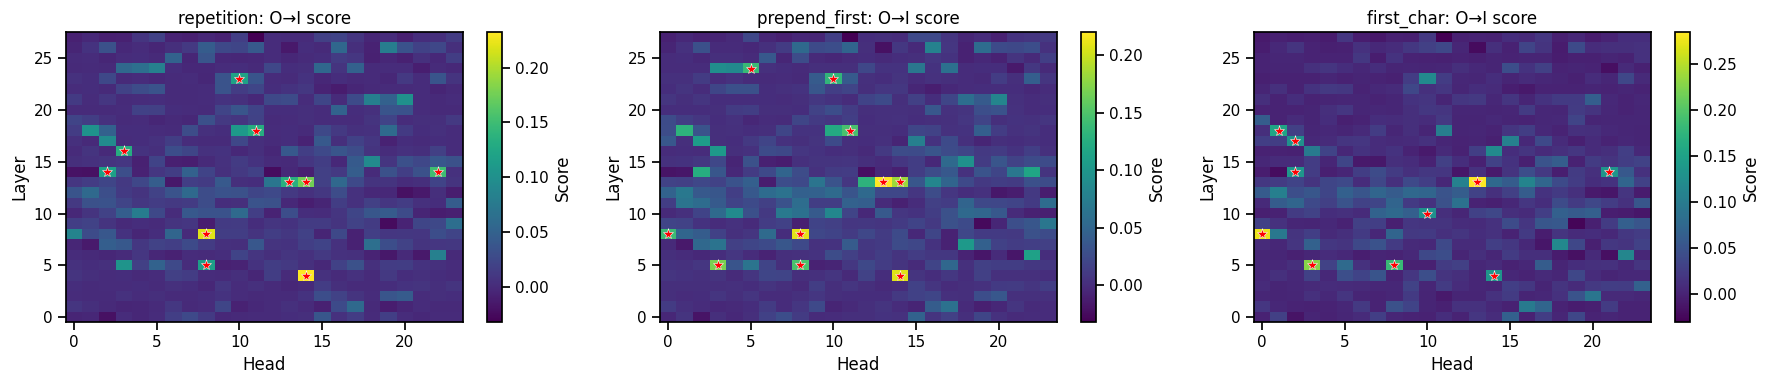

In [26]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
if hasattr(axes, "flatten"): axes = axes.flatten()
else: axes = [axes]
for ax, name in zip(axes, TASK_NAMES):
    sc = task_scores[name]['score']
    im = ax.imshow(sc, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(im, ax=ax, label='Score')
    ax.set_xlabel('Head'); ax.set_ylabel('Layer')
    ax.set_title(f'{name}: O→I score')
    flat = sorted([(L, h, sc[L, h]) for L in range(n_layers) for h in range(n_heads)],
                  key=lambda x: -x[2])
    for L, h, _ in flat[:10]:
        ax.plot(h, L, 'r*', markersize=8, markeredgecolor='white', markeredgewidth=0.4)
for ax in axes[len(TASK_NAMES):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

## Build top-10% and matched random head sets per task, plus ablation eval

In [27]:
def heads_by_layer_from(head_list):
    d = defaultdict(list)
    for L, h in head_list: d[L].append(h)
    return d

def make_ablation_hooks(heads_by_layer):
    fwd_hooks = []
    for L, h_list in heads_by_layer.items():
        def hook(z, hook, _h_list=h_list):
            for h in _h_list: z[0, :, h, :] = 0
            return z
        fwd_hooks.append((f'blocks.{L}.attn.hook_z', hook))
    return fwd_hooks

top10pct_n = max(1, int(0.10 * n_layers * n_heads))
all_pairs = [(L, h) for L in range(n_layers) for h in range(n_heads)]

task_top_heads = {}
task_rand_heads = {}
task_ablation_hooks = {}
for name in TASK_NAMES:
    sc = task_scores[name]['score']
    flat = sorted([(L, h, sc[L, h]) for L in range(n_layers) for h in range(n_heads)],
                  key=lambda x: -x[2])
    top10 = [(L, h) for L, h, _ in flat[:top10pct_n]]
    top10_set = set(top10)
    _rng = random.Random(hash(name) % 10**6)
    rand10 = _rng.sample([p for p in all_pairs if p not in top10_set], top10pct_n)
    task_top_heads[name]  = top10
    task_rand_heads[name] = rand10
    task_ablation_hooks[name] = {
        'unablated': [],
        'top10':  make_ablation_hooks(heads_by_layer_from(top10)),
        'rand10': make_ablation_hooks(heads_by_layer_from(rand10)),
    }
    print(f'{name}: top {len(top10)} heads, random control {len(rand10)} heads')

repetition: top 67 heads, random control 67 heads
prepend_first: top 67 heads, random control 67 heads
first_char: top 67 heads, random control 67 heads


In [28]:
ABL_KEYS = ['unablated', 'top10', 'rand10']
ablation_results = {name: {ab: [] for ab in ABL_KEYS} for name in TASK_NAMES}
ablation_rank    = {name: {ab: [] for ab in ABL_KEYS} for name in TASK_NAMES}

for name in TASK_NAMES:
    hooks_by_ab = task_ablation_hooks[name]
    for pdata in tqdm(TASKS[name], desc=f'{name} ablation'):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        last = tokens.shape[1] - 1
        ans = pdata['query_output']
        for ab_key in ABL_KEYS:
            hooks = hooks_by_ab[ab_key]
            ablation_results[name][ab_key].append(
                check_correct_multitoken(model, tokens, ans, hooks=hooks if hooks else None))
            with torch.no_grad():
                if hooks:
                    logits = model.run_with_hooks(tokens, fwd_hooks=hooks)[0, last]
                else:
                    logits = model(tokens)[0, last]
            ablation_rank[name][ab_key].append(answer_rank(model, logits, ans))
        torch.cuda.empty_cache()
    for ab in ABL_KEYS:
        ablation_results[name][ab] = np.array(ablation_results[name][ab])
        ablation_rank[name][ab]    = np.array(ablation_rank[name][ab])

first_char ablation: 100%|██████████| 50/50 [00:12<00:00,  4.09it/s]


/tmp/ipykernel_3502812/3935759815.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='value', order=ab_order_lab,
/tmp/ipykernel_3502812/3935759815.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='value', order=ab_order_lab,
/tmp/ipykernel_3502812/3935759815.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='value', order=ab_order_lab,


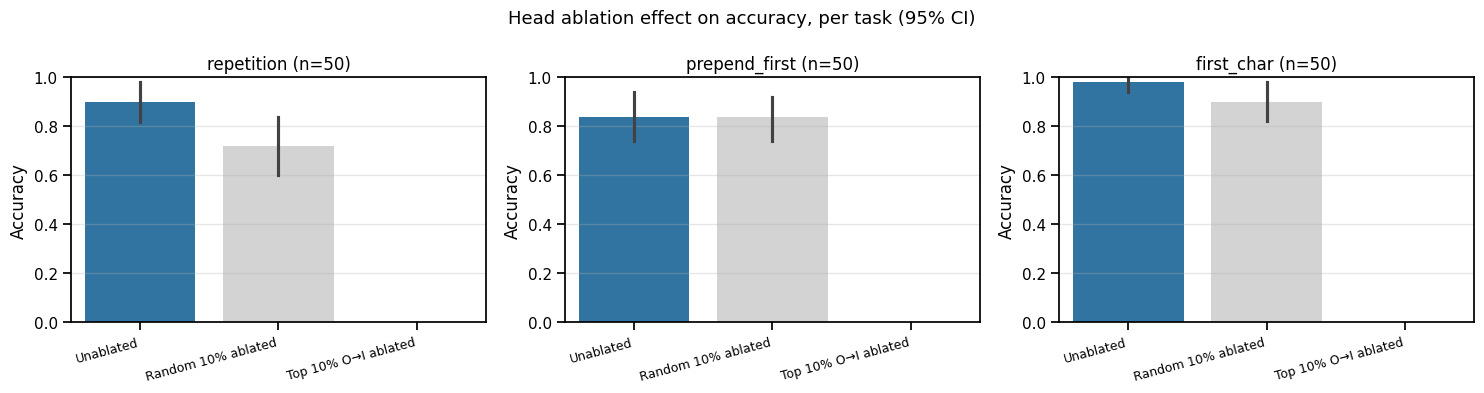

In [29]:
ab_label = {'unablated': 'Unablated', 'top10': 'Top 10% O→I ablated', 'rand10': 'Random 10% ablated'}
ab_palette = {'Unablated': 'tab:blue', 'Top 10% O→I ablated': 'tab:red', 'Random 10% ablated': 'lightgray'}
ab_order_lab = ['Unablated', 'Random 10% ablated', 'Top 10% O→I ablated']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if hasattr(axes, "flatten"): axes = axes.flatten()
else: axes = [axes]
for ax, name in zip(axes, TASK_NAMES):
    n_p = len(ablation_results[name]['unablated'])
    rows = []
    for ab in ABL_KEYS:
        for v in ablation_results[name][ab]:
            rows.append({'Ablation': ab_label[ab], 'value': v})
    df = pd.DataFrame(rows)
    sns.barplot(data=df, x='Ablation', y='value', order=ab_order_lab,
                palette=[ab_palette[a] for a in ab_order_lab],
                errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylabel('Accuracy'); ax.set_xlabel('')
    ax.set_ylim(0, 1.0)
    ax.set_title(f'{name} (n={n_p})')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
for ax in axes[len(TASK_NAMES):]: ax.set_visible(False)
fig.suptitle('Head ablation effect on accuracy, per task (95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

/tmp/ipykernel_3502812/492420680.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='value', order=ab_order_lab,
/tmp/ipykernel_3502812/492420680.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='value', order=ab_order_lab,
/tmp/ipykernel_3502812/492420680.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='value', order=ab_order_lab,


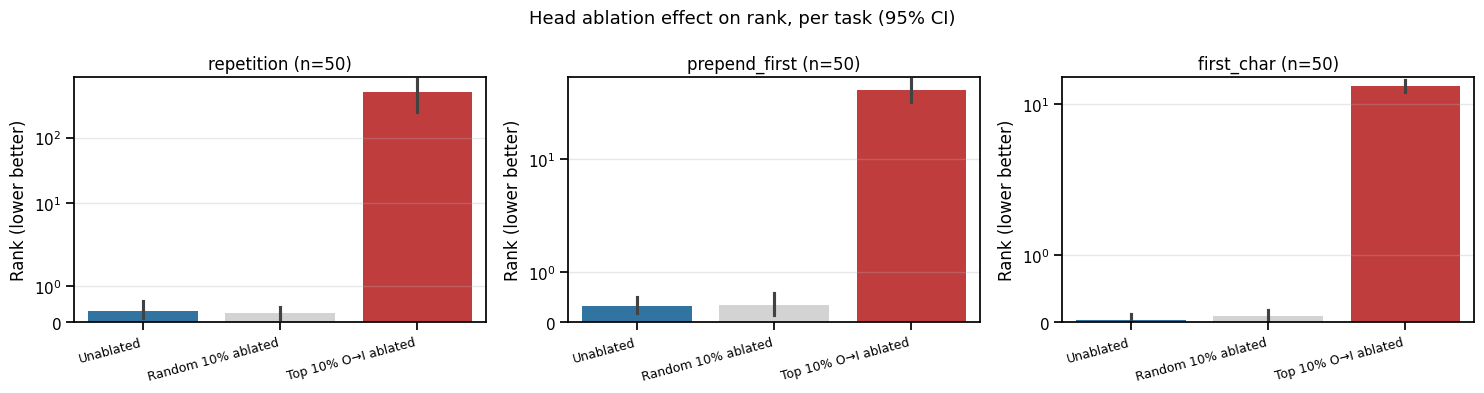

In [30]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if hasattr(axes, "flatten"): axes = axes.flatten()
else: axes = [axes]
for ax, name in zip(axes, TASK_NAMES):
    n_p = len(ablation_rank[name]['unablated'])
    rows = []
    for ab in ABL_KEYS:
        for v in ablation_rank[name][ab]:
            rows.append({'Ablation': ab_label[ab], 'value': v})
    df = pd.DataFrame(rows)
    sns.barplot(data=df, x='Ablation', y='value', order=ab_order_lab,
                palette=[ab_palette[a] for a in ab_order_lab],
                errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylabel('Rank (lower better)'); ax.set_xlabel('')
    ax.set_yscale('symlog')
    ax.set_title(f'{name} (n={n_p})')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
for ax in axes[len(TASK_NAMES):]: ax.set_visible(False)
fig.suptitle('Head ablation effect on rank, per task (95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

## Cross-task head overlap

Compare the top-10% head sets across all tasks. Pairwise overlap matrix shows how similar the heads identified by each task are.

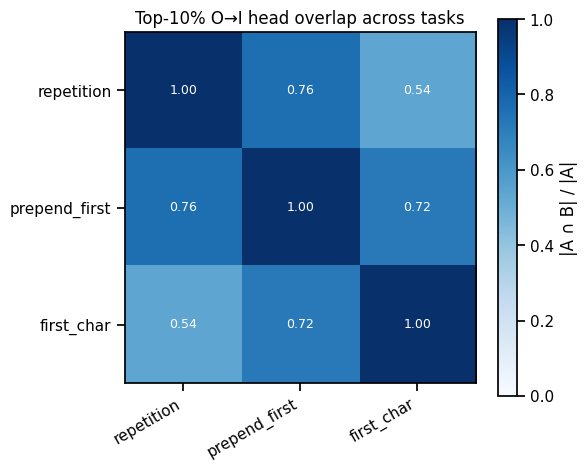

: 

In [31]:
overlap_mat = np.zeros((n_t, n_t))
for i, n1 in enumerate(TASK_NAMES):
    for j, n2 in enumerate(TASK_NAMES):
        s1 = set(task_top_heads[n1]); s2 = set(task_top_heads[n2])
        overlap_mat[i, j] = len(s1 & s2) / max(len(s1), 1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(overlap_mat, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='|A ∩ B| / |A|')
ax.set_xticks(range(n_t)); ax.set_yticks(range(n_t))
ax.set_xticklabels(TASK_NAMES, rotation=30, ha='right')
ax.set_yticklabels(TASK_NAMES)
for i in range(n_t):
    for j in range(n_t):
        ax.text(j, i, f'{overlap_mat[i, j]:.2f}', ha='center', va='center',
                color='white' if overlap_mat[i, j] > 0.5 else 'black', fontsize=9)
ax.set_title('Top-10% O→I head overlap across tasks')
plt.tight_layout(); plt.show()